In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
def create_loan_dataset(n=800):
    """
    Creates a realistic synthetic loan dataset.
    Features: income, credit_score, loan_amount, employment_years,
              debt_to_income, education_level, has_collateral
    Target: loan_approved (0/1)
    
    TRUE patterns baked in:
    - High credit score + stable income → more likely approved
    - High debt_to_income → more likely rejected
    - Has collateral → slight boost
    - Education and employment years matter moderately
    """
    np.random.seed(RANDOM_STATE)
 
    income = np.random.normal(60000, 20000, n).clip(15000, 150000)
    credit_score = np.random.normal(650, 80, n).clip(300, 850).astype(int)
    loan_amount = np.random.normal(150000, 60000, n).clip(20000, 500000)
    employment_years = np.random.exponential(5, n).clip(0, 30).astype(int)
    debt_to_income = np.random.beta(2, 5, n) * 0.8
 
    # education: 0=HighSchool, 1=Bachelor, 2=Master, 3=PhD
    education = np.random.choice([0, 1, 2, 3], n, p=[0.3, 0.4, 0.2, 0.1])
    has_collateral = np.random.choice([0, 1], n, p=[0.6, 0.4])
 
    # --- Build approval probability from TRUE patterns ---
    # Credit score is the biggest driver (normalized to 0-1)
    credit_score_norm = (credit_score - 300) / 550
    income_norm = (income - 15000) / 135000
    dti_penalty = debt_to_income * 2       # higher DTI = bad
    employment_boost = np.log1p(employment_years) / np.log1p(30)
    education_boost = education * 0.05
    collateral_boost = has_collateral * 0.1
 
    approval_prob = (
        0.4 * credit_score_norm +
        0.25 * income_norm +
        0.15 * employment_boost +
        0.05 * education_boost +
        0.05 * collateral_boost -
        dti_penalty * 0.3 +
        0.05
    ).clip(0, 1)
 
    # Add noise so it's not perfectly separable (real world is messy)
    noise = np.random.normal(0, 0.1, n)
    approval_prob = (approval_prob + noise).clip(0, 1)
    loan_approved = (approval_prob > 0.5).astype(int)
 
    df = pd.DataFrame({
        "income": income.astype(int),
        "credit_score": credit_score,
        "loan_amount": loan_amount.astype(int),
        "employment_years": employment_years,
        "debt_to_income": debt_to_income.round(3),
        "education_level": education,
        "has_collateral": has_collateral,
        "loan_approved": loan_approved
    })
    return df
 
 
df = create_loan_dataset(n=800)
 
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution (loan_approved):")
print(df["loan_approved"].value_counts())
print(f"\nApproval rate: {df['loan_approved'].mean()*100:.1f}%")
print("\nSummary statistics:")
print(df.describe().round(2))


Dataset shape: (800, 8)

First 5 rows:
   income  credit_score  loan_amount  employment_years  debt_to_income  \
0   69934           725       139026                 4           0.520   
1   57234           608       232492                 0           0.182   
2   72953           657       111242                 0           0.235   
3   90460           613       102048                15           0.136   
4   55316           615       121035                 1           0.277   

   education_level  has_collateral  loan_approved  
0                0               1              0  
1                1               0              0  
2                2               1              0  
3                2               0              1  
4                2               1              0  

Class distribution (loan_approved):
loan_approved
0    709
1     91
Name: count, dtype: int64

Approval rate: 11.4%

Summary statistics:
          income  credit_score  loan_amount  employment_years  deb

In [5]:
X = df.drop(columns=["loan_approved"])
y = df["loan_approved"].values

In [ ]:
classes, counts = np.unique(y, return_counts=True)
print(classes, counts)

[0 1] [709  91]


In [11]:
def gini_impurity(y):
    """
    Gini = 1 - sum(p_i^2) for all classes i.
    WHY: if you randomly pick two samples, what's the probability
    they belong to DIFFERENT classes? Pure node = 0 (always same class).
    """
    if len(y) == 0:
        return 0
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs ** 2)
 
 
def entropy(y):
    """
    Entropy = -sum(p_i * log2(p_i)) for all classes i.
    WHY: measures "uncertainty" or "disorder" in a node.
    0 = completely pure, 1 = maximum disorder (50/50 binary split).
    """
    if len(y) == 0:
        return 0
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    # np.where to avoid log(0) — 0*log(0) is defined as 0 by convention
    return -np.sum(np.where(probs > 0, probs * np.log2(probs), 0))
 
 
def information_gain(y_parent, y_left, y_right):
    """
    IG = Entropy(parent) - weighted_avg_entropy(children)
    WHY weighted average: a split that creates 100 pure samples on one
    side and 1 impure sample on the other is almost as good as a
    perfectly pure split — we weight by sample count to reflect this.
    """
    n = len(y_parent)
    n_left, n_right = len(y_left), len(y_right)
    parent_entropy = entropy(y_parent)
    weighted_child_entropy = (n_left/n) * entropy(y_left) + (n_right/n) * entropy(y_right)
    return parent_entropy - weighted_child_entropy
 
 
def weighted_gini(y_parent, y_left, y_right):
    """
    Gini gain = Gini(parent) - weighted_avg_Gini(children)
    Same weighting logic as information gain, just using Gini instead of entropy.
    """
    n = len(y_parent)
    n_left, n_right = len(y_left), len(y_right)
    parent_gini = gini_impurity(y_parent)
    weighted_child_gini = (n_left/n) * gini_impurity(y_left) + (n_right/n) * gini_impurity(y_right)
    return parent_gini - weighted_child_gini

In [12]:
print("=" * 60)
print("MANUAL FIRST-SPLIT CALCULATION")
print("=" * 60)
print(f"\nParent node: {len(y)} samples")
print(f"Parent Gini: {gini_impurity(y):.4f}")
print(f"Parent Entropy: {entropy(y):.4f}")
 
features_to_test = ["credit_score", "debt_to_income", "income"]
 
for feature in features_to_test:
    vals = X[feature].values
    # Test 20 candidate thresholds evenly spaced between min and max
    thresholds = np.percentile(vals, np.linspace(10, 90, 20))
 
    best_gain = -1
    best_threshold = None
 
    for thresh in thresholds:
        left_mask = vals <= thresh
        right_mask = vals > thresh
        y_left = y[left_mask]
        y_right = y[right_mask]
 
        if len(y_left) == 0 or len(y_right) == 0:
            continue
 
        gain = weighted_gini(y, y_left, y_right)
        if gain > best_gain:
            best_gain = gain
            best_threshold = thresh
 
    left_mask = vals <= best_threshold
    print(f"\nFeature: {feature}")
    print(f"  Best threshold: {best_threshold:.2f}")
    print(f"  Gini gain: {best_gain:.4f}")
    print(f"  Left child ({left_mask.sum()} samples): "
          f"approval rate = {y[left_mask].mean()*100:.1f}%")
    print(f"  Right child ({(~left_mask).sum()} samples): "
          f"approval rate = {y[~left_mask].mean()*100:.1f}%")
 
print("\n>>> The feature with the HIGHEST Gini gain wins the first split. <<<")
print(">>> This should be credit_score since we baked it in as the top driver. <<<")
 

MANUAL FIRST-SPLIT CALCULATION

Parent node: 800 samples
Parent Gini: 0.2016
Parent Entropy: 0.5111

Feature: credit_score
  Best threshold: 695.00
  Gini gain: 0.0100
  Left child (555 samples): approval rate = 6.7%
  Right child (245 samples): approval rate = 22.0%

Feature: debt_to_income
  Best threshold: 0.20
  Gini gain: 0.0108
  Left child (384 samples): approval rate = 19.0%
  Right child (416 samples): approval rate = 4.3%

Feature: income
  Best threshold: 56888.87
  Gini gain: 0.0050
  Left child (350 samples): approval rate = 5.7%
  Right child (450 samples): approval rate = 15.8%

>>> The feature with the HIGHEST Gini gain wins the first split. <<<
>>> This should be credit_score since we baked it in as the top driver. <<<


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    # stratify=y: ensures the train/test split maintains the SAME class
    # ratio as the original dataset. Without this, a random split might
    # accidentally put almost all the "approved" loans in train and
    # "rejected" loans in test, making evaluation misleading.
)
 
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train approval rate: {y_train.mean()*100:.1f}%")
print(f"Test approval rate:  {y_test.mean()*100:.1f}%")
print("(Both rates should be close due to stratify=y)")

Train: 640 samples | Test: 160 samples
Train approval rate: 11.4%
Test approval rate:  11.2%
(Both rates should be close due to stratify=y)


In [21]:
from sklearn.tree import DecisionTreeClassifier,plot_tree,export_text
from sklearn.metrics import accuracy_score

In [16]:
deep_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
deep_tree.fit(X_train, y_train)
 
train_acc_deep = accuracy_score(y_train, deep_tree.predict(X_train))
test_acc_deep = accuracy_score(y_test, deep_tree.predict(X_test))
 
print("Deep Tree (no depth limit):")
print(f"  Tree depth:       {deep_tree.get_depth()}")
print(f"  Number of leaves: {deep_tree.get_n_leaves()}")
print(f"  Train accuracy:   {train_acc_deep:.4f}")
print(f"  Test accuracy:    {test_acc_deep:.4f}")
print(f"\n  Gap: {(train_acc_deep - test_acc_deep)*100:.2f}% — this IS overfitting.")
print("  A 100% train accuracy means the tree MEMORIZED the training data,")
print("  not learned the true pattern — it will fail on new data.")

Deep Tree (no depth limit):
  Tree depth:       13
  Number of leaves: 82
  Train accuracy:   1.0000
  Test accuracy:    0.8313

  Gap: 16.87% — this IS overfitting.
  A 100% train accuracy means the tree MEMORIZED the training data,
  not learned the true pattern — it will fail on new data.


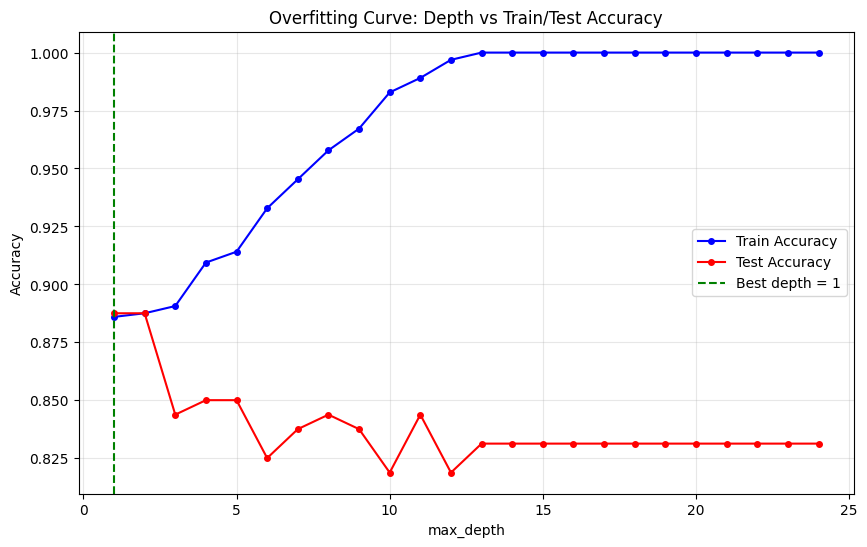

Best depth by test accuracy: 1
Best test accuracy at this depth: 0.8875

Notice: train accuracy keeps climbing as depth increases (tree
memorizes more), but test accuracy PEAKS then DROPS (overfitting).


In [18]:
depths = range(1, 25)
train_accs = []
test_accs = []
 
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))
 
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, "b-o", label="Train Accuracy", markersize=4)
plt.plot(depths, test_accs, "r-o", label="Test Accuracy", markersize=4)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Curve: Depth vs Train/Test Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
 
# Find best depth (highest test accuracy)
best_depth = depths[np.argmax(test_accs)]
plt.axvline(best_depth, color="green", linestyle="--",
            label=f"Best depth = {best_depth}")
plt.legend()
plt.show()
 
print(f"Best depth by test accuracy: {best_depth}")
print(f"Best test accuracy at this depth: {max(test_accs):.4f}")
print("\nNotice: train accuracy keeps climbing as depth increases (tree")
print("memorizes more), but test accuracy PEAKS then DROPS (overfitting).")
 

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"]

}
 
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,               # 5-fold cross-validation
    scoring="accuracy",
    n_jobs=-1,          # use all CPU cores (faster)
    verbose=0
)
grid_search.fit(X_train, y_train)
 
print("GridSearchCV Results:")
print(f"  Best parameters: {grid_search.best_params_}")
print(f"  Best CV accuracy (on training folds): {grid_search.best_score_:.4f}")
 

GridSearchCV Results:
  Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10}
  Best CV accuracy (on training folds): 0.8812


In [20]:
best_dt = grid_search.best_estimator_
test_acc_tuned = accuracy_score(y_test, best_dt.predict(X_test))
print(f"  Test accuracy with best params: {test_acc_tuned:.4f}")
print(f"  (vs untuned deep tree test accuracy: {test_acc_deep:.4f})")
print(f"\nBest tree depth: {best_dt.get_depth()}")
print(f"Best tree leaves: {best_dt.get_n_leaves()}")

  Test accuracy with best params: 0.8438
  (vs untuned deep tree test accuracy: 0.8313)

Best tree depth: 3
Best tree leaves: 7


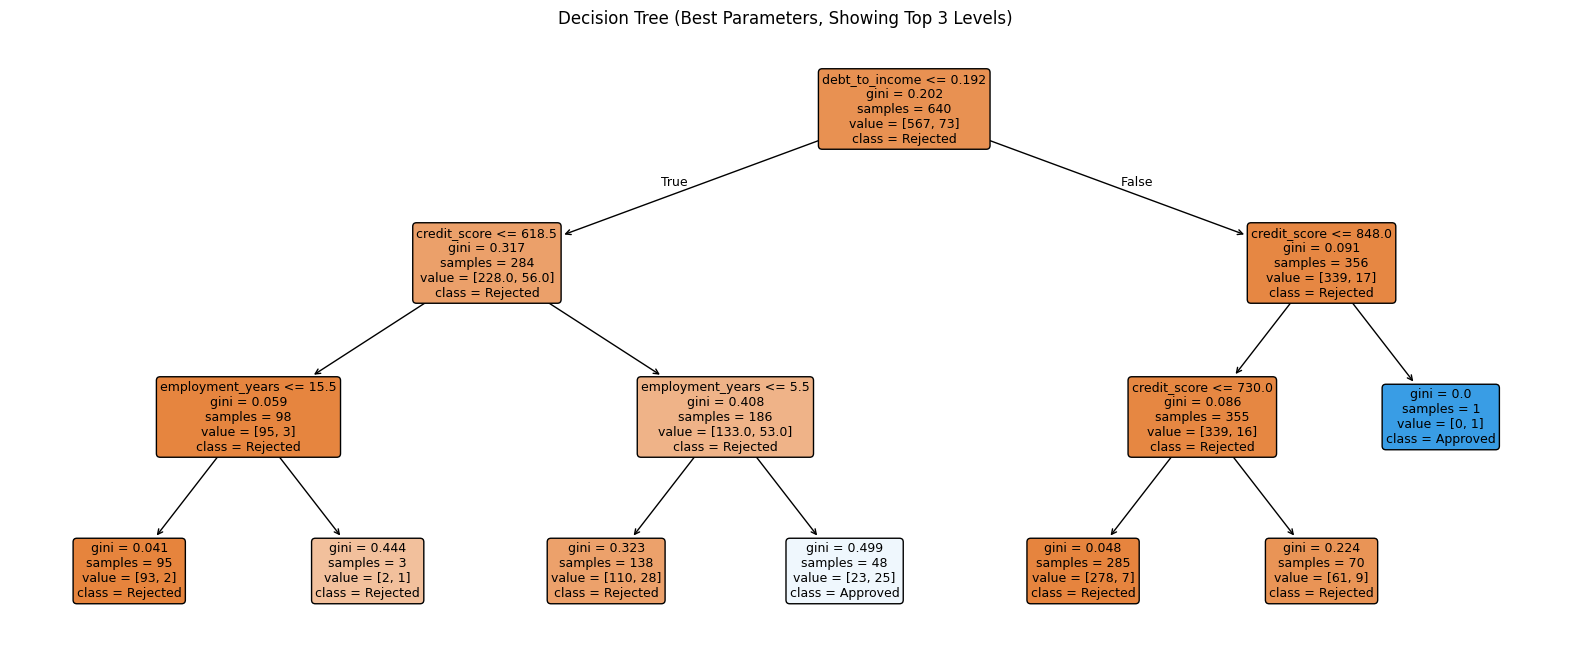


Text representation of top 3 levels:
|--- debt_to_income <= 0.19
|   |--- credit_score <= 618.50
|   |   |--- employment_years <= 15.50
|   |   |   |--- class: 0
|   |   |--- employment_years >  15.50
|   |   |   |--- class: 0
|   |--- credit_score >  618.50
|   |   |--- employment_years <= 5.50
|   |   |   |--- class: 0
|   |   |--- employment_years >  5.50
|   |   |   |--- class: 1
|--- debt_to_income >  0.19
|   |--- credit_score <= 848.00
|   |   |--- credit_score <= 730.00
|   |   |   |--- class: 0
|   |   |--- credit_score >  730.00
|   |   |   |--- class: 0
|   |--- credit_score >  848.00
|   |   |--- class: 1

HOW TO READ THIS TREE:
Each node shows:
  - Feature and threshold used for the split
  - gini: impurity of this node (0=pure, 0.5=worst)
  - samples: how many training samples reached this node
  - value: [count_class_0, count_class_1]
  - class: majority class at this node (prediction if we stopped here)


In [23]:
plt.figure(figsize=(20, 8))
plot_tree(
    best_dt,
    feature_names=X.columns.tolist(),
    class_names=["Rejected", "Approved"],
    filled=True,        # color nodes by majority class
    rounded=True,
    max_depth=3,        # show only top 3 levels (full tree is too large)
    fontsize=9
)
plt.title("Decision Tree (Best Parameters, Showing Top 3 Levels)")
plt.show()
 
# Text representation for the top levels (very useful for debugging)
print("\nText representation of top 3 levels:")
print(export_text(best_dt, feature_names=X.columns.tolist(), max_depth=3))
 
print("HOW TO READ THIS TREE:")
print("Each node shows:")
print("  - Feature and threshold used for the split")
print("  - gini: impurity of this node (0=pure, 0.5=worst)")
print("  - samples: how many training samples reached this node")
print("  - value: [count_class_0, count_class_1]")
print("  - class: majority class at this node (prediction if we stopped here)")

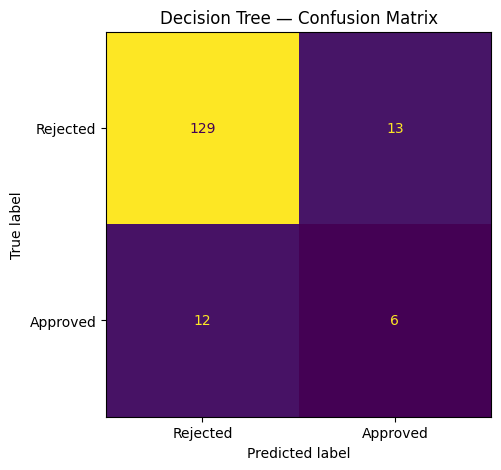

Classification Report (Decision Tree):
              precision    recall  f1-score   support

    Rejected       0.91      0.91      0.91       142
    Approved       0.32      0.33      0.32        18

    accuracy                           0.84       160
   macro avg       0.62      0.62      0.62       160
weighted avg       0.85      0.84      0.85       160

HOW TO READ CLASSIFICATION REPORT:
  Precision: of all predicted 'Approved', what % were actually approved?
             (low precision = too many false positives = risky loans approved)
  Recall:    of all actual 'Approved', what % did we catch?
             (low recall = too many false negatives = valid loans rejected)
  F1:        harmonic mean of precision and recall — balanced measure
  Support:   how many actual samples of each class in the test set


In [24]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay, classification_report
y_pred_dt = best_dt.predict(X_test)
 
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rejected", "Approved"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
plt.title("Decision Tree — Confusion Matrix")
plt.show()
 
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt, target_names=["Rejected", "Approved"]))
 
print("HOW TO READ CLASSIFICATION REPORT:")
print("  Precision: of all predicted 'Approved', what % were actually approved?")
print("             (low precision = too many false positives = risky loans approved)")
print("  Recall:    of all actual 'Approved', what % did we catch?")
print("             (low recall = too many false negatives = valid loans rejected)")
print("  F1:        harmonic mean of precision and recall — balanced measure")
print("  Support:   how many actual samples of each class in the test set")

In [25]:
from sklearn.tree import DecisionTreeRegressor
y_loan_amount = df["loan_amount"].values
 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_loan_amount, test_size=0.2, random_state=RANDOM_STATE
)
 
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
dt_regressor.fit(X_train_r, y_train_r)
 
from sklearn.metrics import mean_squared_error, r2_score
y_pred_reg = dt_regressor.predict(X_test_r)
rmse_reg = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
r2_reg = r2_score(y_test_r, y_pred_reg)
 
print("Decision Tree Regressor (predicting loan amount):")
print(f"  R2 Score: {r2_reg:.4f}")
print(f"  RMSE: ${rmse_reg:,.0f}")
print(f"  Mean actual loan amount: ${y_test_r.mean():,.0f}")
print(f"\nWHAT CHANGES vs Classifier:")
print("  - criterion: 'squared_error' (MSE) instead of 'gini'/'entropy'")
print("  - Leaf prediction: MEAN of samples in leaf, not majority class")
print("  - Evaluation: R2/RMSE instead of accuracy/F1")
print("  - Everything else (splitting logic, depth, pruning) is identical")

Decision Tree Regressor (predicting loan amount):
  R2 Score: 0.9962
  RMSE: $3,765
  Mean actual loan amount: $150,872

WHAT CHANGES vs Classifier:
  - criterion: 'squared_error' (MSE) instead of 'gini'/'entropy'
  - Leaf prediction: MEAN of samples in leaf, not majority class
  - Evaluation: R2/RMSE instead of accuracy/F1
  - Everything else (splitting logic, depth, pruning) is identical
